In [12]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

In [13]:
url = "https://quotes.toscrape.com/"

response = requests.get(url)

print("Status Code:", response.status_code)

Status Code: 200


In [14]:
id="q1w2e3"
quotes = []

for page in range(1, 6):
    url = f"https://quotes.toscrape.com/page/{page}/"
    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")

    for quote in soup.find_all("div", class_="quote"):
        text = quote.find("span", class_="text").get_text(strip=True)
        author = quote.find("small", class_="author").get_text(strip=True)

        tags = [tag.get_text(strip=True) for tag in quote.find_all("a", class_="tag")]
        tags = ", ".join(tags)

        quotes.append({
            "Quote": text,
            "Author": author,
            "Tags": tags
        })

print("Total quotes collected:", len(quotes))

Total quotes collected: 50


In [15]:
df = pd.DataFrame(quotes)

df.head(10)

,Quote,Author,Tags
0,“The world as we have created it is a process ...,Albert Einstein,"change, deep-thoughts, thinking, world"
1,"“It is our choices, Harry, that show what we t...",J.K. Rowling,"abilities, choices"
2,“There are only two ways to live your life. On...,Albert Einstein,"inspirational, life, live, miracle, miracles"
3,"“The person, be it gentleman or lady, who has ...",Jane Austen,"aliteracy, books, classic, humor"
4,"“Imperfection is beauty, madness is genius and...",Marilyn Monroe,"be-yourself, inspirational"
5,“Try not to become a man of success. Rather be...,Albert Einstein,"adulthood, success, value"
6,“It is better to be hated for what you are tha...,André Gide,"life, love"
7,"“I have not failed. I've just found 10,000 way...",Thomas A. Edison,"edison, failure, inspirational, paraphrased"
8,“A woman is like a tea bag; you never know how...,Eleanor Roosevelt,misattributed-eleanor-roosevelt
9,"“A day without sunshine is like, you know, nig...",Steve Martin,"humor, obvious, simile"


In [16]:
df.to_csv("scraped_quotes.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [17]:
print("Number of quotes:", len(df))
print("Number of authors:", df["Author"].nunique())

print("\nTop 10 Authors:")
print(df["Author"].value_counts().head(10))

Number of quotes: 50
Number of authors: 28

Top 10 Authors:
Author
Albert Einstein      8
J.K. Rowling         6
Marilyn Monroe       6
Dr. Seuss            3
Bob Marley           3
Mother Teresa        2
André Gide           1
Jane Austen          1
Steve Martin         1
Eleanor Roosevelt    1
Name: count, dtype: int64


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

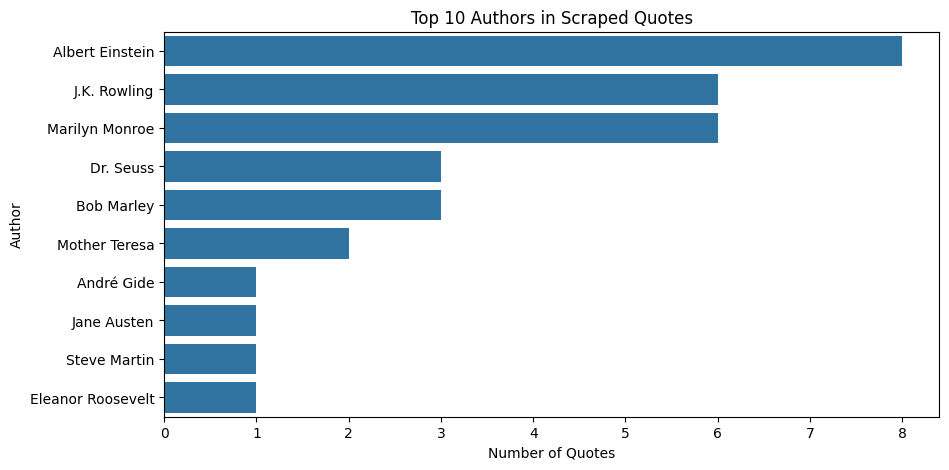

In [19]:
top_authors = df["Author"].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_authors.values, y=top_authors.index)

plt.title("Top 10 Authors in Scraped Quotes")
plt.xlabel("Number of Quotes")
plt.ylabel("Author")
plt.show()

## Key Insights

1. The project successfully collected quotes from multiple webpages.

2. The scraped dataset contains quote text, author names, and tags.

3. The analysis shows the authors who appear most frequently in the scraped data.

4. Web scraping can be used to collect structured information from webpages.

5. The collected data was saved as a CSV file for further analysis.

In [20]:
print("Scraping completed successfully.")
print("Total records:", len(df))
print("Columns:", list(df.columns))

Scraping completed successfully.
Total records: 50
Columns: ['Quote', 'Author', 'Tags']
